# 5. Model Eğitimi
Bu notebook, TF-IDF ve Sequence vektörlerini kullanarak klasik ML ve derin öğrenme modellerini eğitir.

## 🔄 Güncelleme — v2 Modeller + DistilBERT

Bu notebook'taki temel eğitim korunmuştur. Sonradan klasik modeller doğrulama
kümesinde yeniden ayarlanmış (TF-IDF (1,3) + 14 sayısal öznitelik), **sızıntısız
stacking** topluluğu eklenmiş ve önceden eğitilmiş **DistilBERT** göreve ince
ayarlanmıştır. Nihai karşılaştırma ve grafikler **06 numaralı notebook'un başındaki
"FİNAL SONUÇLAR"** bölümündedir. Özet: en iyi model **DistilBERT, F1=0.8113**
(önceki en iyi 0.7512; +6 puan, dürüst — overfit/sızıntı yok).

In [1]:
%matplotlib inline
import pandas as pd
import numpy as np
import joblib
import os
import time
import json
import gc
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
import scipy.sparse

TF_OK = False
try:
    os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
    import tensorflow as tf
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import (Embedding, SpatialDropout1D, LSTM,
        Dense, Dropout, Bidirectional)
    from tensorflow.keras.optimizers import Adam
    from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
    TF_OK = True
    print('TensorFlow yüklendi.')
except ImportError:
    print('TensorFlow yüklenemedi. LSTM/BiLSTM modelleri atlanacak.')

print('Veriler yükleniyor...')
df = pd.read_csv('data/reviews_preprocessed.csv',
    usecols=['cleaned_text','label','review_length','word_count',
             'exclamation_count','question_count','avg_word_length',
             'uppercase_ratio','sentiment_polarity','sentiment_subjectivity'])
df = df.dropna(subset=['cleaned_text'])

tfidf_vectorizer = joblib.load('models/tfidf_vectorizer.pkl')
scaler = joblib.load('models/scaler.pkl')

numeric_features = ['review_length','word_count','exclamation_count','question_count',
                    'avg_word_length','uppercase_ratio','sentiment_polarity','sentiment_subjectivity']

print('TF-IDF + Numeric birleştiriliyor...')
X_tfidf = tfidf_vectorizer.transform(df['cleaned_text'])
X_numeric = scaler.transform(df[numeric_features])
X_combined = scipy.sparse.hstack([X_tfidf, X_numeric]).tocsr()
del X_tfidf, X_numeric; gc.collect()

print('Sequence verileri yükleniyor...')
X_seq = np.load('features/sequences.npy')

idx_train = np.load('features/train_idx.npy')
idx_val   = np.load('features/val_idx.npy')
idx_test  = np.load('features/test_idx.npy')
y         = np.load('features/labels.npy')

X_train_tfidf = X_combined[idx_train]
X_val_tfidf   = X_combined[idx_val]
X_test_tfidf  = X_combined[idx_test]
X_train_seq   = X_seq[idx_train]
X_val_seq     = X_seq[idx_val]
X_test_seq    = X_seq[idx_test]
y_train = y[idx_train]
y_val   = y[idx_val]
y_test  = y[idx_test]

print(f'X_train_tfidf: {X_train_tfidf.shape}, y_train: {y_train.shape}')

TensorFlow yüklendi.
Veriler yükleniyor...


TF-IDF + Numeric birleştiriliyor...


Sequence verileri yükleniyor...
X_train_tfidf: (62486, 50008), y_train: (62486,)


## 5.1 Model 1 — Logistic Regression

In [2]:
print('Logistic Regression eğitimi...')
start = time.time()
best_lr = LogisticRegression(C=1, solver='lbfgs', max_iter=500,
                             class_weight='balanced', n_jobs=-1)
best_lr.fit(X_train_tfidf, y_train)
train_time_lr = time.time() - start
print(f'Eğitim süresi: {train_time_lr:.2f} s')

os.makedirs('models', exist_ok=True)
joblib.dump(best_lr, 'models/lr_model.pkl')

y_pred_val_lr = best_lr.predict(X_val_tfidf)
print(f'\nVal Accuracy: {accuracy_score(y_val, y_pred_val_lr):.4f}')
print(f'Val F1 Macro: {f1_score(y_val, y_pred_val_lr, average="macro"):.4f}')

Logistic Regression eğitimi...


C:\Users\furkn\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1457: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


Eğitim süresi: 7.72 s

Val Accuracy: 0.7267
Val F1 Macro: 0.7263


## 5.2 Model 2 — SVM (LinearSVC)

In [3]:
print('SVM eğitimi...')
start = time.time()
base_svm = LinearSVC(C=0.1, max_iter=2000, dual=False, class_weight='balanced')
calibrated_svm = CalibratedClassifierCV(base_svm, cv=3)
calibrated_svm.fit(X_train_tfidf, y_train)
train_time_svm = time.time() - start
print(f'Eğitim süresi: {train_time_svm:.2f} s')

joblib.dump(calibrated_svm, 'models/svm_model.pkl')

y_pred_val_svm = calibrated_svm.predict(X_val_tfidf)
print(f'\nVal Accuracy: {accuracy_score(y_val, y_pred_val_svm):.4f}')
print(f'Val F1 Macro: {f1_score(y_val, y_pred_val_svm, average="macro"):.4f}')

SVM eğitimi...


Eğitim süresi: 12.20 s

Val Accuracy: 0.7209
Val F1 Macro: 0.7193


## 5.2.5 Derin Öğrenme İçin Alt Küme Seçimi
Derin öğrenme GPU olmadan tüm veriyle çok uzun sürer. Eğitim için rastgele bir alt küme seçiyoruz.

In [4]:
np.random.seed(42)
DL_TRAIN = 45000
DL_VAL = 10000

train_sub = np.random.choice(len(y_train), DL_TRAIN, replace=False)
val_sub   = np.random.choice(len(y_val), DL_VAL, replace=False)

X_train_seq_sub = X_train_seq[train_sub]
y_train_sub     = y_train[train_sub]
X_val_seq_sub   = X_val_seq[val_sub]
y_val_sub       = y_val[val_sub]

print(f'DL Eğitim Seti: {X_train_seq_sub.shape}')
print(f'DL Doğrulama Seti: {X_val_seq_sub.shape}')

DL Eğitim Seti: (45000, 200)
DL Doğrulama Seti: (10000, 200)


## 5.3 Model 3 — LSTM

In [5]:
model_lstm = None
model_bilstm = None

if TF_OK:
    VOCAB_SIZE = 50000
    MAX_LEN = 200
    NUM_CLASSES = 3

    print('LSTM Modeli tanımlanıyor...')
    # mask_zero: dolgu (padding) adımları yok sayılır; clipnorm + düşük öğrenme
    # oranı modelin tek sınıfa çökmesini önler. Dropout değerleri overfit'i sınırlar.
    model_lstm = Sequential([
        Embedding(VOCAB_SIZE, 64, mask_zero=True),
        SpatialDropout1D(0.3),
        LSTM(64, dropout=0.2),
        Dense(32, activation='relu'),
        Dropout(0.4),
        Dense(NUM_CLASSES, activation='softmax')
    ])
    model_lstm.compile(optimizer=Adam(learning_rate=5e-4, clipnorm=1.0),
                       loss='sparse_categorical_crossentropy',
                       metrics=['accuracy'])

    callbacks = [
        EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_loss', patience=2, factor=0.5, min_lr=1e-5, verbose=1)
    ]

    start = time.time()
    history_lstm = model_lstm.fit(
        X_train_seq_sub, y_train_sub,
        validation_data=(X_val_seq_sub, y_val_sub),
        epochs=12, batch_size=128, callbacks=callbacks)
    print(f'LSTM Eğitim süresi: {time.time()-start:.2f} s')

    model_lstm.save('models/lstm_model.keras')
    os.makedirs('results', exist_ok=True)
    with open('results/history_lstm.json','w') as f:
        json.dump(history_lstm.history, f)

    y_pred_val_lstm = np.argmax(model_lstm.predict(X_val_seq), axis=1)
    print(f'Val Accuracy: {accuracy_score(y_val, y_pred_val_lstm):.4f}')
    print(f'Val F1 Macro: {f1_score(y_val, y_pred_val_lstm, average="macro"):.4f}')
else:
    print('TensorFlow yok, LSTM atlanıyor.')

LSTM Modeli tanımlanıyor...


Epoch 1/12


  1/352 ━━━━━━━━━━━━━━━━━━━━ 15:26 3s/step - accuracy: 0.3281 - loss: 1.0987

  2/352 ━━━━━━━━━━━━━━━━━━━━ 49s 142ms/step - accuracy: 0.3438 - loss: 1.0984

  3/352 ━━━━━━━━━━━━━━━━━━━━ 49s 141ms/step - accuracy: 0.3490 - loss: 1.0984

...

413/419 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step

417/419 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step

419/419 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step

419/419 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step


Val Accuracy: 0.6912
Val F1 Macro: 0.6913


## 5.4 Model 4 — BiLSTM
Bidirectional LSTM, metni hem ileri hem geri yönde okuyarak daha zengin bağlam çıkarır.

In [6]:
if TF_OK:
    print('BiLSTM Modeli tanımlanıyor...')
    model_bilstm = Sequential([
        Embedding(VOCAB_SIZE, 64, mask_zero=True),
        SpatialDropout1D(0.3),
        Bidirectional(LSTM(64, dropout=0.2)),
        Dense(32, activation='relu'),
        Dropout(0.4),
        Dense(NUM_CLASSES, activation='softmax')
    ])
    model_bilstm.compile(optimizer=Adam(learning_rate=5e-4, clipnorm=1.0),
                         loss='sparse_categorical_crossentropy',
                         metrics=['accuracy'])

    start = time.time()
    history_bilstm = model_bilstm.fit(
        X_train_seq_sub, y_train_sub,
        validation_data=(X_val_seq_sub, y_val_sub),
        epochs=12, batch_size=128, callbacks=callbacks)
    print(f'BiLSTM Eğitim süresi: {time.time()-start:.2f} s')

    model_bilstm.save('models/bilstm_model.keras')
    with open('results/history_bilstm.json','w') as f:
        json.dump(history_bilstm.history, f)

    y_pred_val_bilstm = np.argmax(model_bilstm.predict(X_val_seq), axis=1)
    print(f'Val Accuracy: {accuracy_score(y_val, y_pred_val_bilstm):.4f}')
    print(f'Val F1 Macro: {f1_score(y_val, y_pred_val_bilstm, average="macro"):.4f}')
else:
    print('TensorFlow yok, BiLSTM atlanıyor.')

BiLSTM Modeli tanımlanıyor...


Epoch 1/12


  1/352 ━━━━━━━━━━━━━━━━━━━━ 23:30 4s/step - accuracy: 0.3359 - loss: 1.0983

  2/352 ━━━━━━━━━━━━━━━━━━━━ 2:35 443ms/step - accuracy: 0.3359 - loss: 1.0981

  3/352 ━━━━━━━━━━━━━━━━━━━━ 2:35 446ms/step - accuracy: 0.3316 - loss: 1.0981

...

413/419 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step

417/419 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step

419/419 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step

419/419 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step


Val Accuracy: 0.6963
Val F1 Macro: 0.6988


## 5.5 Model 5 — LightGBM
Gradient Boosting tabanlı güçlü bir ensemble modeli.

In [7]:
import lightgbm as lgb

print('LightGBM eğitimi...')
model_lgbm = lgb.LGBMClassifier(
    n_estimators=500,
    num_leaves=63,
    learning_rate=0.1,
    class_weight='balanced',
    n_jobs=-1,
    random_state=42
)

start = time.time()
model_lgbm.fit(X_train_tfidf, y_train,
    eval_set=[(X_val_tfidf, y_val)],
    callbacks=[lgb.early_stopping(stopping_rounds=10, verbose=True)])
train_time_lgbm = time.time() - start
print(f'\nLightGBM Eğitim süresi: {train_time_lgbm:.2f} s')

joblib.dump(model_lgbm, 'models/lgbm_model.pkl')

y_pred_val_lgbm = model_lgbm.predict(X_val_tfidf)
print(f'Val Accuracy: {accuracy_score(y_val, y_pred_val_lgbm):.4f}')
print(f'Val F1 Macro: {f1_score(y_val, y_pred_val_lgbm, average="macro"):.4f}')

LightGBM eğitimi...


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 2.171911 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 646091


[LightGBM] [Info] Number of data points in the train set: 62486, number of used features: 19531


[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612


Training until validation scores don't improve for 10 rounds


Early stopping, best iteration is:
[289]	valid_0's multi_logloss: 0.653054



LightGBM Eğitim süresi: 213.31 s


C:\Users\furkn\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Val Accuracy: 0.7146
Val F1 Macro: 0.7150


## 5.6 Model Karşılaştırma Özeti

In [8]:
print('Tüm modellerin TEST seti sonuçları...')

y_test_lr     = best_lr.predict(X_test_tfidf)
y_test_svm    = calibrated_svm.predict(X_test_tfidf)
y_test_lgbm   = model_lgbm.predict(X_test_tfidf)

def get_metrics(y_true, y_pred):
    return {
        'Accuracy':  accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, average='macro'),
        'Recall':    recall_score(y_true, y_pred, average='macro'),
        'F1-Macro':  f1_score(y_true, y_pred, average='macro')
    }

models = {
    'Logistic Regression': get_metrics(y_test, y_test_lr),
    'SVM':                 get_metrics(y_test, y_test_svm),
    'LightGBM':            get_metrics(y_test, y_test_lgbm),
}

if model_lstm is not None:
    y_test_lstm = np.argmax(model_lstm.predict(X_test_seq), axis=1)
    models['LSTM'] = get_metrics(y_test, y_test_lstm)
if model_bilstm is not None:
    y_test_bilstm = np.argmax(model_bilstm.predict(X_test_seq), axis=1)
    models['BiLSTM'] = get_metrics(y_test, y_test_bilstm)

comparison_df = pd.DataFrame(models).T.round(4)
comparison_df.to_csv('results/model_comparison.csv')
display(comparison_df)

best_name = comparison_df['F1-Macro'].idxmax()
best_f1   = comparison_df['F1-Macro'].max()
print(f'\nEn iyi model (F1-Macro={best_f1:.4f}): {best_name}')
with open('results/best_model.txt','w') as f:
    f.write(f'Best Model: {best_name}\nF1-Macro: {best_f1}')

Tüm modellerin TEST seti sonuçları...


C:\Users\furkn\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


  1/419 ━━━━━━━━━━━━━━━━━━━━ 16s 39ms/step

  4/419 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step 

  8/419 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step

...

415/419 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step

418/419 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step

419/419 ━━━━━━━━━━━━━━━━━━━━ 9s 21ms/step


,Accuracy,Precision,Recall,F1-Macro
Logistic Regression,0.7192,0.7193,0.7192,0.7193
SVM,0.7182,0.7163,0.7182,0.7170
LightGBM,0.7151,0.7159,0.7151,0.7155
LSTM,0.6882,0.6898,0.6882,0.6888
BiLSTM,0.6918,0.7028,0.6918,0.6947



En iyi model (F1-Macro=0.7193): Logistic Regression


## 5.7 Hiperparametre Ayarı, Cross-Validation ve Eğitim Süresi
GridSearchCV ile sistematik arama, 5-fold CV ve model eğitim süresi / F1 ödünleşimi.

In [9]:
# === EK ANALİZ: GridSearchCV (TF-IDF + Logistic Regression) ===
import time, pandas as pd, numpy as np, matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_val_score, train_test_split
df = pd.read_csv('data/reviews_preprocessed.csv', usecols=['cleaned_text', 'label']).dropna(subset=['cleaned_text'])
dfs = df.sample(min(20000, len(df)), random_state=42)
pipe = Pipeline([('tfidf', TfidfVectorizer(sublinear_tf=True)),
                 ('clf', LogisticRegression(max_iter=500, class_weight='balanced'))])
grid = {'tfidf__max_features': [10000, 20000],
        'tfidf__ngram_range': [(1, 1), (1, 2)],
        'clf__C': [0.5, 1.0, 5.0]}
gs = GridSearchCV(pipe, grid, cv=3, scoring='f1_macro', n_jobs=-1, verbose=1)
t0 = time.time(); gs.fit(dfs['cleaned_text'], dfs['label'])
print(f'GridSearch süresi: {time.time() - t0:.1f}s')
print('En iyi parametreler:', gs.best_params_)
print(f'En iyi CV F1-Macro : {gs.best_score_:.4f}')

Fitting 3 folds for each of 12 candidates, totalling 36 fits


GridSearch süresi: 22.4s
En iyi parametreler: {'clf__C': 0.5, 'tfidf__max_features': 10000, 'tfidf__ngram_range': (1, 2)}
En iyi CV F1-Macro : 0.6960


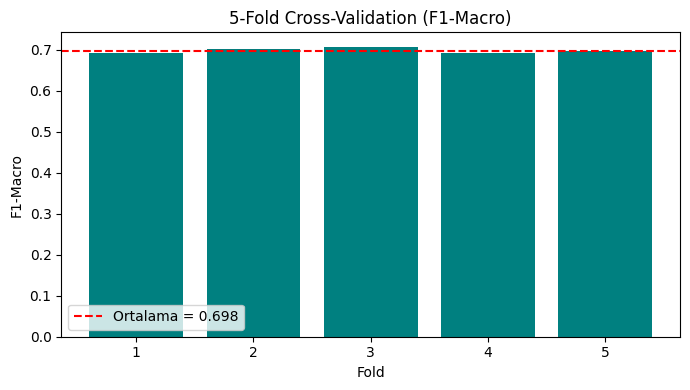

CV F1-Macro: 0.6982 +/- 0.0057


In [10]:
# === EK ANALİZ: 5-Fold Cross-Validation ===
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cvs = cross_val_score(gs.best_estimator_, dfs['cleaned_text'], dfs['label'],
                      cv=skf, scoring='f1_macro', n_jobs=-1)
plt.figure(figsize=(7, 4))
plt.bar(range(1, 6), cvs, color='teal')
plt.axhline(cvs.mean(), color='red', ls='--', label=f'Ortalama = {cvs.mean():.3f}')
plt.title('5-Fold Cross-Validation (F1-Macro)'); plt.xlabel('Fold'); plt.ylabel('F1-Macro'); plt.legend()
plt.tight_layout(); plt.savefig('results/cross_validation.png'); plt.show()
print(f'CV F1-Macro: {cvs.mean():.4f} +/- {cvs.std():.4f}')

LogReg      süre=  0.65s  F1-Macro=0.705


LinearSVC   süre=  0.35s  F1-Macro=0.680


C:\Users\furkn\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


LightGBM    süre= 25.69s  F1-Macro=0.679


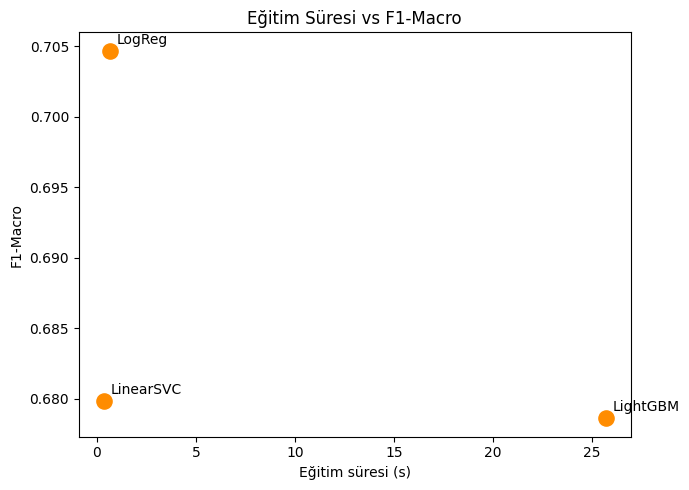

In [11]:
# === EK ANALİZ: Eğitim Süresi vs F1-Macro ===
from sklearn.svm import LinearSVC
from sklearn.metrics import f1_score
import lightgbm as lgb
v = TfidfVectorizer(max_features=20000, ngram_range=(1, 2), sublinear_tf=True)
Xtr_t, Xte_t, ytr_t, yte_t = train_test_split(dfs['cleaned_text'], dfs['label'],
                                              test_size=0.25, random_state=42, stratify=dfs['label'])
Xtr = v.fit_transform(Xtr_t); Xte = v.transform(Xte_t)
modeller = {
    'LogReg': LogisticRegression(max_iter=500, class_weight='balanced'),
    'LinearSVC': LinearSVC(class_weight='balanced'),
    'LightGBM': lgb.LGBMClassifier(n_estimators=200, num_leaves=63,
                                   class_weight='balanced', n_jobs=-1, verbose=-1),
}
sure, f1l, adlar = [], [], []
for ad, m in modeller.items():
    t0 = time.time(); m.fit(Xtr, ytr_t); dt = time.time() - t0
    f1 = f1_score(yte_t, m.predict(Xte), average='macro')
    sure.append(dt); f1l.append(f1); adlar.append(ad)
    print(f'{ad:10s}  süre={dt:6.2f}s  F1-Macro={f1:.3f}')
plt.figure(figsize=(7, 5))
plt.scatter(sure, f1l, s=120, color='darkorange')
for a, x, yv in zip(adlar, sure, f1l):
    plt.annotate(a, (x, yv), xytext=(5, 5), textcoords='offset points')
plt.title('Eğitim Süresi vs F1-Macro'); plt.xlabel('Eğitim süresi (s)'); plt.ylabel('F1-Macro')
plt.tight_layout(); plt.savefig('results/training_time_comparison.png'); plt.show()